# Single Cell Sanity Check
To ensure weird results are not due to faults in the code pipeline, we'll briefly check if data is trimmed correctly.

## Imports

In [59]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import hic_mask_threshold, import_cool, fetch_region

# Import data
sc_file = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data/arc_pair_20032.cool'
sc_cool = import_cool(sc_file)
sc_chr1 = fetch_region(sc_cool, chrom="chr1")
sc_chr1_upper = hic_mask_threshold(sc_chr1, 0, "raw", "none")[0]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Visualizing Data Distributions

Text(0.5, 1.0, 'Data Distribution for Raw SC Data File (20032)')

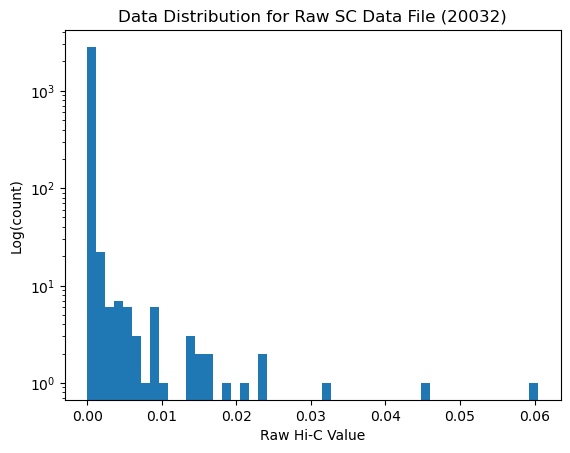

In [20]:
### Raw Data ###
plt.hist(sc_chr1_upper, log=True, bins=50)
plt.xlabel("Raw Hi-C Value")
plt.ylabel("Log(count)")
plt.title("Data Distribution for Raw SC Data File (20032)")

Text(0.5, 1.0, 'Data Distribution for Sum Normalized SC Data File (20032)')

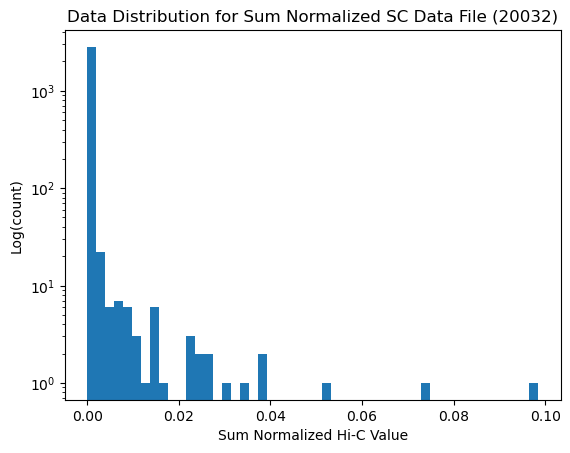

In [62]:
### Sum Normalized Data ###
sum_norm = hic_mask_threshold(sc_chr1, 0, "raw", "sum")[0]
plt.hist(sum_norm, log=True, bins=50)
plt.xlabel("Sum Normalized Hi-C Value")
plt.ylabel("Log(count)")
plt.title("Data Distribution for Sum Normalized SC Data File (20032)")

1e-06
Element Ratio: 0.7104260478004849


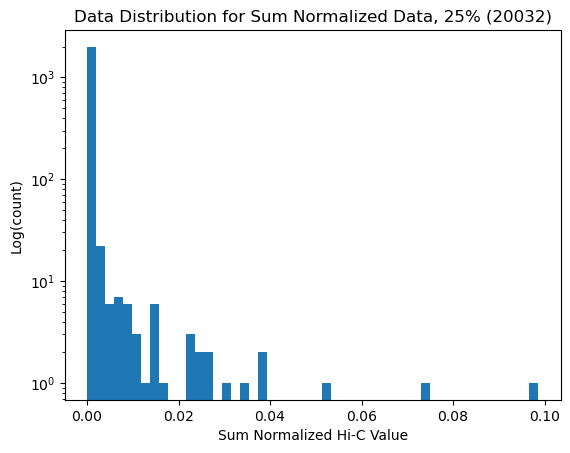

In [67]:
### Sum Normalized Data, 25% Threshold ###
sum_norm_25 = hic_mask_threshold(sc_chr1, 25, "percentile", "sum")[0]
plt.hist(sum_norm_25, log=True, bins=50)
plt.xlabel("Sum Normalized Hi-C Value")
plt.ylabel("Log(count)")
plt.title("Data Distribution for Sum Normalized Data, 25% (20032)")
print("Element Ratio:", len(sum_norm_25)/len(sum_norm))